# Estatística 1 - Aula prática 4_2 em Python

## UNIDADE 4: Testes de hipóteses paramétricos e intervalos de confiança

### Seção 4.3: Paired test

By Jose P. Leitão

### Teste de duas amostras emparelhadas - paired Z test

In [ ]:
# Carregando as bibliotecas
%matplotlib inline

# Importar bibliotecas
import numpy as np

import pandas as pd

from scipy.stats import norm, t, shapiro, f, ttest_ind, ttest_rel

from statsmodels.stats.weightstats import ztest

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

Carregando a base de dados "bigpaired_weight.RData". Trata-se
de uma amostra emparelhada com dois grupos, antes e depois de
um tratamento de alimentacao para camundongos. Os camundongos
foram pesados antes e depois do tratamento, vamos ver a base 
de dados

In [2]:
df = pd.read_csv('bigpaired_weight.csv')

df.head()

,group,weight
0,before,262.329341
1,before,256.127491
2,before,242.118090
3,before,232.185318
4,before,243.636869


Vamos fazer checagens preliminares para verificar as exigencias do teste: Amostras independentes, normalidade e homogeneidade das variancias entre os grupos

Premissa 1: A amostra se refere a dados emparelhados, e eh uma grande amostra?
- Sim, pois os camundongos foram pesados antes e depois do tratamento. A amostra possui dados emparelhados de 100 camundongos.

Premissa 2: Os dados de cada grupo da amostra seguem uma distribuicao normal?  
Vamos usar o teste de normalidade Shapiro-Wilk com o seguinte teste de hipoteses:

 - H0: os dados sao normalmente distribuidos
 - Ha: os dados nao sao normalmente distribuidos

 Primeiro calculamos a diferenca entre os pares e guardamos no objeto "d"

In [31]:
d1 = df.query("group == 'before'")['weight'].to_numpy() - df.query("group == 'after'")['weight'].to_numpy()

Executando o teste Shapiro-Wilk para normalidade

In [32]:
stat, p = shapiro(d1)
print(f"p-value : {p:.4f}")     
# p-value>0.05 (ou seja, 0.5098), logo o grupo possui 
# distribuicao normal

p-value : 0.5098


Pelos resultados dos testes, os dois valores de p sao maiores do que o nivel de significancia 0.05, o que implica que a distribuicao dos dados nao eh significativamente diferente da distribuicao normal. 

Em outras palavras, podemos assumir que os dois grupos possuem distribuicao normal.

Observe que se os dados nao forem normalmente distribuidos, eh recomendavel usar outro teste de duas amostras nao parametrico.

Premissa 3. As duas populacoes/amostras/grupos possuem homogeneidade das variancias?  
O teste de hipoteses eh o seguinte:

- H0: As variancias sao estatisticamente iguais(homogeneas) 
- HA: As variancias nao sao estatisticamente iguais(homogeneas)

Usaremos o teste F para testar a homogeneidade nas variancias.

In [33]:
import numpy as np
from scipy import stats

def f_test(sample1, sample2, alpha=0.05):
    """
    Perform a two-tailed F-test to compare variances of two samples.
    
    Parameters:
        sample1 (list/array): First dataset
        sample2 (list/array): Second dataset
        alpha (float): Significance level (default 0.05)
    
    Returns:
        dict: F-statistic, p-value, and test conclusion
    """
    # Convert to numpy arrays
    x = np.array(sample1, dtype=float)
    y = np.array(sample2, dtype=float)

    # Validate input
    if x.size < 2 or y.size < 2:
        raise ValueError("Both samples must have at least two values.")
    if np.any(np.isnan(x)) or np.any(np.isnan(y)):
        raise ValueError("Samples must not contain NaN values.")

    # Calculate variances
    var_x = np.var(x, ddof=1)  # sample variance
    var_y = np.var(y, ddof=1)

    # F-statistic (larger variance / smaller variance)
    if var_x > var_y:
        f_stat = var_x / var_y
        dfn, dfd = len(x) - 1, len(y) - 1
    else:
        f_stat = var_y / var_x
        dfn, dfd = len(y) - 1, len(x) - 1

    # Two-tailed p-value
    p_value = 2 * min(
        stats.f.cdf(f_stat, dfn, dfd),
        1 - stats.f.cdf(f_stat, dfn, dfd)
    )

    # Conclusion
    reject_null = p_value < alpha

    return {
        "F-statistic": f_stat,
        "p-value": p_value,
        "Reject Null (variances equal)": reject_null
    }

In [34]:
x1 = df.loc[df["group"] == 'before', ['weight']].to_numpy()
x2 = df.loc[df["group"] == 'after', ['weight']].to_numpy()

result = f_test(x1, x2, alpha=0.05)

print("F-statistic:", result["F-statistic"])
print("p-value:", result["p-value"])
print("Reject Null Hypothesis:", result["Reject Null (variances equal)"])

F-statistic: 1.0811128589825991
p-value: 0.6987765238882564
Reject Null Hypothesis: False


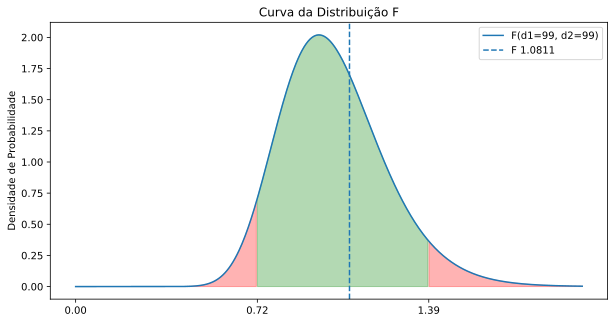

In [35]:
F = result["F-statistic"]

# graus de liberdade
dfn = len(x1) - 1   # grau de liberdade do numerador
dfd = len(x2) - 1   # grau de liberdade do denominador

# significância
alfa = 0.05 # 5%

# intervalo de valores
x = np.linspace(0, 2, 500)

# função densidade da distribuição F
y = f.pdf(x, dfn, dfd)

# valores críticos
q2 = f.ppf(1-alfa, dfn, dfd)
q1 = 1/q2

# plot
plt.figure(figsize=(10,5))
plt.plot(x, y, label=f'F(d1={dfd}, d2={dfn})')
plt.fill_between(x, y, where=((x < q1) | (x > q2)), alpha= 0.3, color='red')
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ), alpha=0.3, color='green')

plt.axvline(F,linestyle="--", label=f"F {F:.4f}")

plt.title('Curva da Distribuição F')
plt.xticks([0, q1, q2])
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
plt.ylabel('Densidade de Probabilidade')
plt.legend()


plt.show()

O teste de F tem valores criticos entre 0.72 e  1.39 (regiao 
de nao rejeicao), os valores acima de 1,39 e abaixo de 0.72 
estao na regiao de rejeicao de H0 (area vermelha do grafico). O
valor da estatistica F calculada eh 1.0811, esse valor se
encontra na regiao de nao rejeicao de H0. Entao, nao rejeitamos 
a hipotese de que as variancias sao estatisticamente iguais.

Feitas essas checagens preliminares, como os grupos sao
emparelhados, normalmente distribuidos e possuem variancia
homogenea, agora podemos fazer o teste de Z para duas amostras/
grupos e responder a seguinte pergunta:

Existe alguma diferenca significativa entre o peso dos 
camundongos antes e depois do tratamento?

Para responder executamos o seguinte teste de hipoteses:

- H0: A diferenca verdadeira entre os pesos dos camundongos antes
    e depois do tratamento eh igual a zero,ou seja, as medias
    sao estatisticamente iguais
- HA: A diferenca verdadeira entre os pesos dos camundongos antes
    e depois do tratamento nao eh igual a zero, ou seja, as
    medias nao sao estatisticamente iguais

In [41]:
# Fazendo o teste:
z_stat, p_value = ztest(d1, value=0)

print(f"Z-stat : {z_stat:.2f}")
print(f"p-value : {p_value:.6f}")

Z-stat : -109.62
p-value : 0.000000


No resultado:  
a) "Z" eh o valor estatistico do teste (Z = -109.62);  
b) "p-value" eh o nivel de significancia do teste Z (valor de p = 0.00000000000000022);   
c) O intervalo de confianca da diferenca entre as medias a 95% de confianca se situa entre -206.9199 e -199.6509;  
d) "sample estimates" eh o valor da media de cada grupo da amostra (media da diferenca entre antes e depois eh igual a 203,2854.

In [42]:
# Obtendo os valores tabelados da estatistica Z
print(norm.ppf(0.975))
print(norm.ppf(0.025))

1.959963984540054
-1.9599639845400545


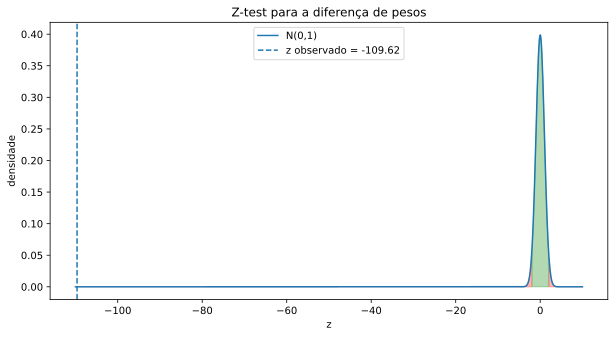

In [45]:
# Vamos construir o gráfico da distribuição Z

# significância
alfa = 0.05 # 5%

# valores para plot
x = np.linspace(-110, 10, 1000)
y = norm.pdf(x)

plt.figure(figsize=(10,5))
plt.plot(x, y, label="N(0,1)")

# limites críticos
z_crit = norm.ppf(1 - alfa/2)

# regiões críticas
# Rejeição de H0
plt.fill_between(x, y, where=((x < -z_crit) | (x > z_crit)), alpha=0.3, color='red')

# Não Rejeição de H0
plt.fill_between(x, y, where=((x >= -z_crit) & (x <= z_crit) ), alpha=0.3, color='green')

# linha do z observado
plt.axvline(z_stat, linestyle="--", label=f"z observado = {z_stat:.2f}")

plt.title("Z-test para a diferença de pesos")
plt.xlabel("z")
plt.ylabel("densidade")
plt.legend()

plt.show()


Os valores tabelados/criticos da distribuicao Z sao -1.96 e 
1.96 (regiao de nao rejeicao de H0), com 95% de confianca ou
5% de significancia. Os valores acima de 1.96 e abaixo de 
-1.96 sao as regioes de rejeicao de H0 (areas vermelhas do 
grafico). 
Como o valor Z calculado eh -109.62 (menor que -1.96) ele se
encontra na regiao de rejeicao de H0. Sendo assim, rejeitamos
a hipotese (H0) de que as medias sejam estatisticamente iguais,
ou seja, o peso medio dos camundongos antes do tratamento eh 
estatisticamente diferente do peso medio dos camundongos apos
o tratamento.

Outra forma de interpretar:
O valor de p do teste eh 0.00000000000000022, que eh menor que
o nivel de significancia 0,05 (5% de significancia ou 95% de
confianca). Esse p-value se situa na area de rejeicao de H0,
logo rejeita-se H0.
Conclui-se que peso medio dos camundongos antes do tratamento
eh estatisticamente diferente do peso medio apos o tratamento.
Portanto, como as medias sao estatisticamente diferentes e em
termos absolutos/nominais o peso medio dos camundongos apos o
tratamento eh maior que o peso medio antes do tratamento. 
Entao os camundongos efetivamente engordaram.

Vamos confirmar o resultado com o teste de Welch


In [46]:
result = ttest_ind(x1, x2, equal_var=False)

print(result)

TtestResult(statistic=array([-105.03627622]), pvalue=array([2.16981297e-175]), df=array([197.69967319]))


O teste de Welch confirmou o que o teste de Z apresentou

In [ ]:
# Entao, como a media apos o tratamento eh 450,3031 e antes do
# tratamento eh 247,0177 , se dividirmos um pelo outro temos:
# 450.3031/247.0177
print(f"O peso médio dos camundogos aumentou {np.mean(x2)/np.mean(x1)-1 :.2%} após o tratamento")


O peso médio dos camundogos aumentou 82.30% após o tratamento


### Teste de duas amostras emparelhadas - paired t test 

Carregando a base de dados "paired_weight.RData". Trata-se de
uma amostra emparelhada com dois grupos, antes e depois de um
tratamento de alimentacao de camundongos. Os camundongos 
foram pesados antes e depois do tratamento, vamos ver a base
de dados

Essa nao eh a mesma base de dados do "teste Z" (acima), esta
eh uma pequena amostra de um outro experimento

In [52]:
df = pd.read_csv('paired_weight.csv')
print(df.shape)

(20, 2)


Queremos saber se existe alguma diferenca significativa nos pesos dos ratos apos o tratamento

In [57]:
df.describe()

,weight
count,20.000000
mean,296.405000
std,102.593072
min,172.200000
25%,196.100000
50%,293.250000
75%,392.925000
max,434.000000


Checagem preliminar para verificar as exigencias do teste t 
pareado

Premissa 1: As duas amostras estao emparelhadas?
Sim, uma vez que os dados foram coletados pesando os mesmos 
ratos (emparelhamento).

Premissa 2: Esta eh uma amostra grande e normalmente
            distribuida?
Nao, n<30. Como o tamanho da amostra nao eh grande o suficiente
(menos de 30), usamos o teste de t para dados pareados, mas
antes precisamos verificar se as diferencas dos pares seguem
uma distribuicao normal. Usamos o teste de normalidade 
Shapiro-Wilk, com as seguintes hipoteses

- H0: os dados sao normalmente distribuidos
- Ha: os dados nao sao normalmente distribuidos

Primeiro calculamos a diferenca entre os pares e guardamos no
objeto "d"

In [58]:
d = df.query("group == 'before'")['weight'].to_numpy() - df.query("group == 'after'")['weight'].to_numpy()

In [ ]:
#  Agora aplicamos o teste de Shapiro-Wilk para (d)
stat, p = shapiro(d)
print(f"p-value : {p:.4f}")     
# p-value>0.05 (ou seja, 0.6141), logo o grupo possui 
# distribuicao normal

p-value : 0.6141


No resultado, o p-value eh maior do que o nivel de 
significancia 0.05, o que implica que a distribuicao das
diferencas (d) nao eh significativamente diferente da
distribuicao normal.
Em outras palavras, podemos assumir a normalidade dos dados.

Premissa 3: As duas populacoes/amostras/grupos possuem
             homogeneidade das variancias?
O teste de hipoteses eh:

- H0: As variancias sao estatisticamente iguais(homogeneas) 
- HA: As variancias nao sao estatisticamente iguais(homogeneas)

Usaremos o teste F para testar a homogeneidade nas variancias: 

In [60]:
x1 = df.loc[df["group"] == 'before', ['weight']].to_numpy()
x2 = df.loc[df["group"] == 'after', ['weight']].to_numpy()

result = f_test(x1, x2, alpha=0.05)

print("F-statistic:", result["F-statistic"])
print("p-value:", result["p-value"])
print("Reject Null Hypothesis:", result["Reject Null (variances equal)"])

F-statistic: 2.532419604589891
p-value: 0.18251058548175725
Reject Null Hypothesis: False


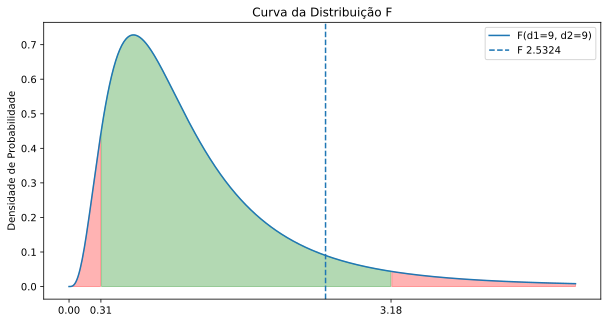

In [62]:
F = result["F-statistic"]

# graus de liberdade
dfn = len(x1) - 1   # grau de liberdade do numerador
dfd = len(x2) - 1   # grau de liberdade do denominador

# significância
alfa = 0.05 # 5%

# intervalo de valores
x = np.linspace(0, 5, 500)

# função densidade da distribuição F
y = f.pdf(x, dfn, dfd)

# valores críticos
q2 = f.ppf(1-alfa, dfn, dfd)
q1 = 1/q2

# plot
plt.figure(figsize=(10,5))
plt.plot(x, y, label=f'F(d1={dfd}, d2={dfn})')
plt.fill_between(x, y, where=((x < q1) | (x > q2)), alpha= 0.3, color='red')
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ), alpha=0.3, color='green')

plt.axvline(F,linestyle="--", label=f"F {F:.4f}")

plt.title('Curva da Distribuição F')
plt.xticks([0, q1, q2])
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
plt.ylabel('Densidade de Probabilidade')
plt.legend()


plt.show()

O teste de F, com valor critico entre 0.31 e 3.18 (area de nao
rejeicao de H0), os valores acima de 3.18 e abaixo de 0.31 
estao na regiao de rejeicao de H0 (area vermelha do grafico). O
valor da estatistica F calculada no teste eh 2.5324. Como esse
valor se encontra na regiao de nao rejeicao, entao nao 
rejeitamos a hipotese de que as variancias sao estatisticamente
iguais.

Observe que se os individuos nao forem emparelhados, devemos
utilizar um teste para amostras independentes. Se os dados
nao forem normalmente distribuidos, e as variancias nao forem
homogeneas eh recomendavel usar o teste de duas amostras 
emparelhadas nao parametrico.

Apos essas averiguacoes iniciais podemos executar o teste para
a diferenca das medias emparelhadas com a seguinte pergunta:

Existe alguma mudanca significativa no peso dos ratos apos o
tratamento?

- H0: O peso dos ratos eh estatisticamente igual antes e depois do tratamento
- HA: O peso dos ratos nao eh estatisticamente igual antes e depois do tratamento

In [ ]:
# Fazendo o teste:

x1 = df.loc[df["group"] == 'before', ['weight']].to_numpy()
x2 = df.loc[df["group"] == 'after', ['weight']].to_numpy()

result = ttest_rel(a=x2, b=x1)

t_stastistic = result.statistic[0]

ci_inf, ci_sup = result.confidence_interval(0.95)

In [ ]:
print(f"t = {t_stastistic:.3f}")
print(f"o grau de liberdade é {result.df[0]}")
print(f"p-value = {result.pvalue[0]:.10f}")
print(f"os intervalos de confiança são {ci_inf[0]:.2f} e {ci_sup[0]:.2f}")
print(f"A média da diferença das amostras é {np.mean(x2-x1):.2f}")

t = 20.883
p-value = 0.0000000062
o grau de liberdade é 9
os intervalos de confiança são 173.42 e 215.56
A média da diferença das amostras é 194.49


No resultado:
a) "t" eh o valor estatistico do teste t (t = 20.883),
b) df sao os graus de liberdade (df = 9),
c) O p-value eh o nivel de significancia do teste t (p-value = 0.0000000062).
d) conf.int eh o intervalo de confianca das diferencas das medias com 95%, que eh entre 173,42 e 215,56
e) A estimativa da media amostral para as diferencas entre  pares eh (media = 194,49).

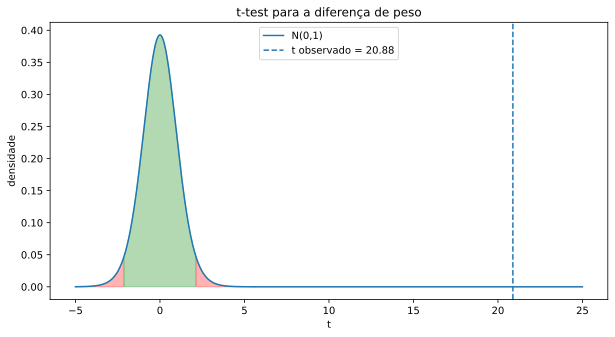

In [80]:
# Vamos construir o gráfico da distribuição t de Student

# significância
alfa = 0.05 # 5%

# valores para plot
x = np.linspace(-5, 25, 1000)
y = t.pdf(x, df=16)

plt.figure(figsize=(10,5))
plt.plot(x, y, label="N(0,1)")

# limites críticos
t_crit = t.ppf(1 - alfa/2, df=16)

# regiões críticas
# Rejeição de H0
plt.fill_between(x, y, where=((x < -t_crit) | (x > t_crit)), alpha=0.3, color='red')

# Não Rejeição de H0
plt.fill_between(x, y, where=((x >= -t_crit) & (x <= t_crit) ), alpha=0.3, color='green')

# linha do z observado
plt.axvline(t_stastistic, linestyle="--", label=f"t observado = {t_stastistic:.2f}")

plt.title("t-test para a diferença de peso")
plt.xlabel("t")
plt.ylabel("densidade")
plt.legend()

plt.show()

Os valores tabelados/criticos de t sao -2,26 e 2,26, que eh o
intervalo da regiao de nao rejeicao de H0, valores menores que
-2,26 e maiores que 2,26 pertencem as regioes de rejeicao de H0.
Como o t calculado eh 20,883 esse valor se encontra na regiao 
de rejeicao de "H0" pois eh maior que 2,26. Logo, rejeitamos 
"H0", e nao rejeitamos "Ha" de que os pesos dos ratos antes e
depois do tratamento nao sao iguais.

Outra forma de interpretar o resultado:
O p-value do teste eh 0.0000000062, que eh menor que o nivel
de significancia 0.05. Podemos entao rejeitar H0, logo nao 
rejeitamos Ha, e concluimos que o peso medio dos camundongos
antes do tratamento eh significativamente diferente do peso
medio apos o tratamento.

Vamos confirmar o resultado com o teste de Welch

In [83]:
result = ttest_ind(x1, x2, equal_var=False)

print(result)

TtestResult(statistic=array([-17.7137735]), pvalue=array([1.54402185e-11]), df=array([15.1490134]))


In [85]:
# O teste de Welch confirmou o que o teste de Z apresentou

# Como o peso medio dos ratos antes o tratamento eh 199 e depois
# do tratamento eh 394, podemos dividir os valores e encontrar:
# 394/199
# Os camundongos engordaram 97,66% apos o tratamento
print(f"O peso médio dos camundogos aumentou {np.mean(x2)/np.mean(x1)-1 :.2%} após o tratamento")

O peso médio dos camundogos aumentou 97.66% após o tratamento
